<a href="https://colab.research.google.com/github/YassineGasmi04/AdultProject-ML-/blob/main/TP_capital_gain_membre6_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Étape 0 : Importer le fichier dans Colab

Cette cellule ouvre une fenêtre pour choisir le fichier CSV sur l'ordinateur. Le nom du fichier s'affiche ensuite sous la cellule.

In [44]:
from google.colab import files
uploaded = files.upload()

Saving adult.data to adult (4).data


## Importer les bibliothèques

* **pandas** et **numpy** : manipuler les données.
* **matplotlib** et **seaborn** : faire des graphiques.
* **scipy** : faire le test du khi-deux (utilisé plus loin pour mesurer le lien entre une variable texte et la cible).
* **sklearn** : encoder et normaliser les données.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, StandardScaler

## Charger le dataset

On lit le fichier CSV. Dans ce dataset, les valeurs inconnues sont écrites avec un point d'interrogation `?`. On demande à pandas de les considérer comme des valeurs manquantes avec `na_values='?'`.

`skipinitialspace=True` supprime les espaces au début des textes (par exemple `" Male"` devient `"Male"`).

Si le nom de ton fichier est différent, il suffit de le changer dans la première ligne.

In [46]:
FICHIER = "adult.data"

df = pd.read_csv(FICHIER, skipinitialspace=True, na_values='?')
df.shape

(32560, 15)

## Uniformiser les noms des colonnes

Selon la source du fichier, les colonnes peuvent s'appeler `capital-gain`, `capital.gain` ou `capital_gain`. On met tous les noms au même format (minuscules avec des tirets) pour que le reste du code fonctionne dans tous les cas.

La dernière ligne enlève le point final qui existe parfois dans la colonne `income` (`>50K.` devient `>50K`).

In [47]:


COLONNES = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
            'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
            'hours-per-week', 'native-country', 'income']

df = pd.read_csv(FICHIER, header=None, names=COLONNES, skipinitialspace=True, na_values='?')
df.shape

(32561, 15)

## Exploration des données

On regarde les premières lignes pour comprendre à quoi ressemblent les données.

In [48]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


On regarde les dernières lignes.

In [49]:
df.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


On affiche les statistiques des variables numériques : moyenne, minimum, maximum, etc.

On remarque que pour `capital-gain`, la médiane (50 %) vaut 0 et même le 75 % vaut 0. Cela veut dire que la grande majorité des personnes n'a **aucun** gain en capital.

In [50]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


On affiche le type de chaque colonne et le nombre de valeurs non vides.

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# Partie 1 : Nettoyage des données

## Les doublons

Un doublon est une ligne qui est exactement identique à une autre. On compte d'abord combien il y en a.

In [52]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 24


On supprime les doublons, car ils comptent la même personne deux fois.

In [53]:
df = df.drop_duplicates()

On vérifie qu'il ne reste plus de doublons.

In [54]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


## Les valeurs manquantes

On compte le nombre de valeurs manquantes dans chaque colonne.

In [55]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


Trois colonnes ont des valeurs manquantes : `workclass`, `occupation` et `native-country`.

Ce sont des colonnes **texte**. On ne peut pas les remplacer par une moyenne. On choisit de remplacer les valeurs manquantes par le mot `Unknown` (inconnu). Ainsi, on ne supprime aucune personne et on n'invente pas de fausse information.

In [56]:
df['workclass'] = df['workclass'].fillna('Unknown')
df['occupation'] = df['occupation'].fillna('Unknown')
df['native-country'] = df['native-country'].fillna('Unknown')

df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


## Visualisation

On affiche l'histogramme de chaque variable numérique.

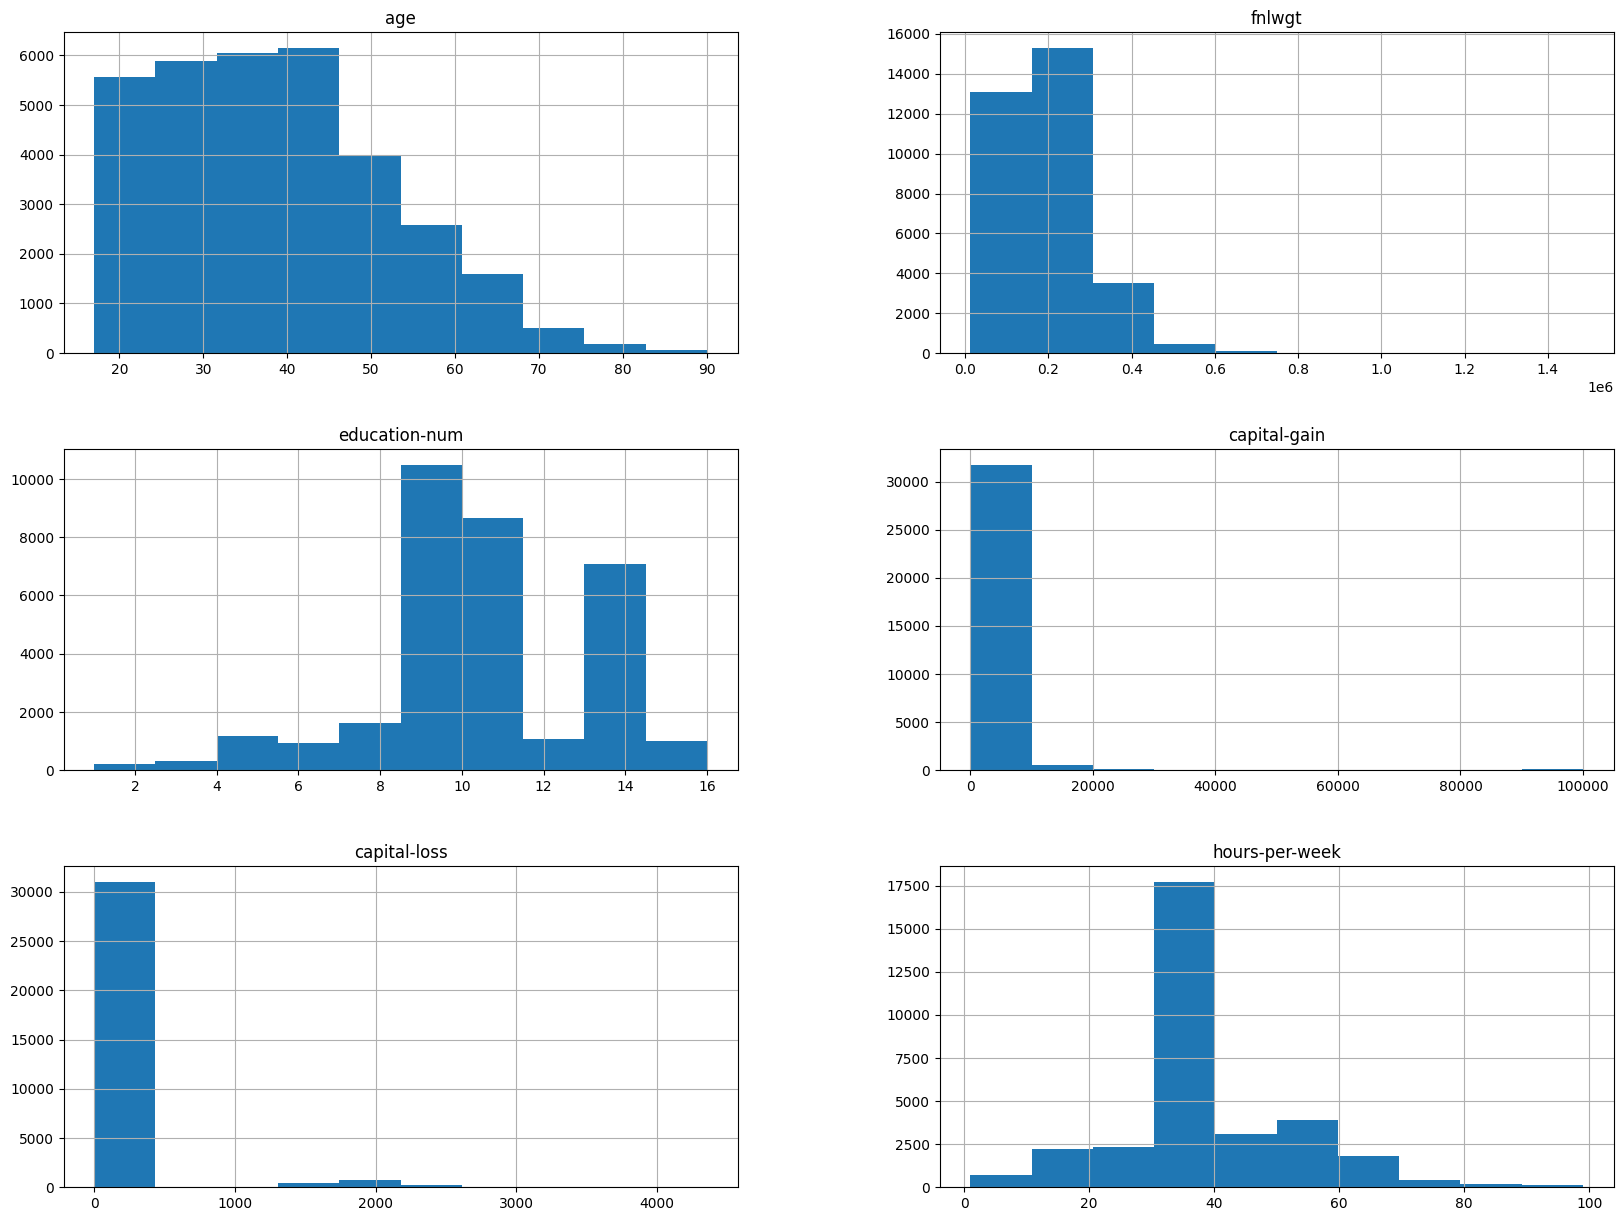

In [57]:
df.hist(figsize=(20, 15))
plt.show()

L'histogramme de `capital-gain` montre une seule grande barre à 0. Presque tout le monde a 0, et seules quelques personnes ont un montant.

C'est pour cette raison qu'on ne cherche pas à prédire le **montant** exact, mais seulement **si la personne a des gains ou non** (oui / non).

# Partie 2 : Création de la cible et des nouvelles variables

## Pourquoi cette partie vient avant la matrice de corrélation ?

* La variable cible n'est pas trouvée par la matrice : elle est **imposée par l'objectif métier** (ligne 6 du tableau).
* Notre cible (« a des gains : oui / non ») **n'existe pas encore** dans le fichier. Il faut la créer pour que la matrice puisse mesurer le lien entre les variables et la cible.
* Les nouvelles variables demandées (tranche d'âge, marié, niveau d'études regroupé) doivent aussi être créées **avant** la matrice, pour pouvoir vérifier si elles sont utiles.

## Créer la variable cible

On crée une nouvelle colonne `has_capital_gain` :
* **1** si `capital-gain` est supérieur à 0 (la personne a des gains en capital) ;
* **0** sinon.

In [58]:
df['has_capital_gain'] = (df['capital-gain'] > 0).astype(int)
target = 'has_capital_gain'

df[target].value_counts()

,count
has_capital_gain,
0,29825
1,2712


On affiche la proportion de chaque classe en pourcentage.

In [59]:
df[target].value_counts(normalize=True) * 100

,proportion
has_capital_gain,
0,91.664874
1,8.335126


On visualise la répartition de la cible.

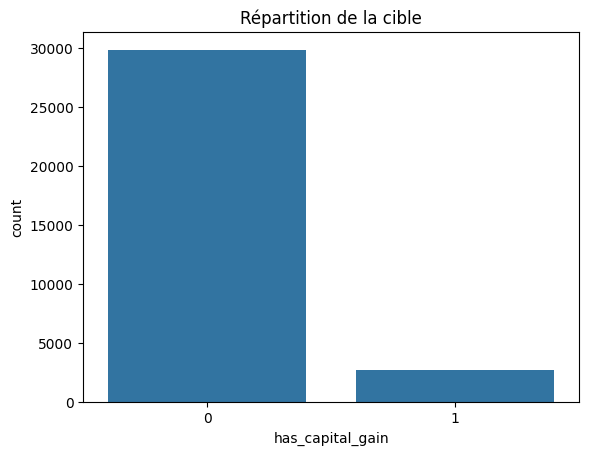

In [60]:
sns.countplot(x=target, data=df)
plt.title("Répartition de la cible")
plt.show()

Seulement environ **8 %** des personnes ont des gains en capital. On dit que la cible est **déséquilibrée**.

C'est important pour la suite : un modèle qui répond toujours « non » aurait 92 % de bonnes réponses tout en étant inutile. Lors de la modélisation, il faudra donc regarder d'autres mesures que l'accuracy (par exemple le rappel ou le F1-score).

## Nouvelle variable 1 : la tranche d'âge

On découpe l'âge en groupes : 17-25, 26-35, 36-45, 46-55, 56-65 et 66+.

**Pourquoi ?** On s'attend à ce que l'épargne augmente avec l'âge, car une personne plus âgée a eu plus de temps pour économiser et investir.

In [61]:
df['tranche_age'] = pd.cut(df['age'],
                           bins=[16, 25, 35, 45, 55, 65, 100],
                           labels=['17-25', '26-35', '36-45', '46-55', '56-65', '66+'])

df[['age', 'tranche_age']].head()

,age,tranche_age
0,39,36-45
1,50,46-55
2,38,36-45
3,53,46-55
4,28,26-35


## Nouvelle variable 2 : l'indicateur « marié »

On crée une colonne `est_marie` :
* **1** si la personne est mariée (`Married-civ-spouse` ou `Married-AF-spouse`) ;
* **0** sinon.

**Pourquoi ?** Un couple marié a souvent une épargne commune et des placements.

In [62]:
df['est_marie'] = df['marital-status'].isin(['Married-civ-spouse', 'Married-AF-spouse']).astype(int)

df[['marital-status', 'est_marie']].head()

,marital-status,est_marie
0,Never-married,0
1,Married-civ-spouse,1
2,Divorced,0
3,Married-civ-spouse,1
4,Married-civ-spouse,1


## Nouvelle variable 3 : le niveau d'études regroupé

La colonne `education` contient 16 niveaux différents, ce qui est beaucoup. On les regroupe en 5 niveaux en utilisant `education-num` (le niveau d'études sous forme de nombre, de 1 à 16) :

| education-num | Groupe |
|---|---|
| 1 à 8 | 1-Sans diplôme secondaire |
| 9 | 2-HS-grad (équivalent du bac) |
| 10 à 12 | 3-Études sup. courtes |
| 13 | 4-Bachelors (licence) |
| 14 à 16 | 5-Master et plus |

**Pourquoi ?** Moins de catégories rend la variable plus simple à utiliser et à interpréter.

In [63]:
def regrouper_education(n):
    if n <= 8:
        return '1-Sans diplome secondaire'
    elif n == 9:
        return '2-HS-grad'
    elif n <= 12:
        return '3-Etudes sup. courtes'
    elif n == 13:
        return '4-Bachelors'
    else:
        return '5-Master et plus'

df['education_groupe'] = df['education-num'].apply(regrouper_education)

df[['education', 'education-num', 'education_groupe']].head()

,education,education-num,education_groupe
0,Bachelors,13,4-Bachelors
1,Bachelors,13,4-Bachelors
2,HS-grad,9,2-HS-grad
3,11th,7,1-Sans diplome secondaire
4,Bachelors,13,4-Bachelors


## Vérifier que les nouvelles variables sont utiles

Pour chaque nouvelle variable, on calcule le **pourcentage de personnes qui ont des gains en capital** dans chaque groupe. La ligne rouge représente la moyenne générale (environ 8 %).

Si les barres sont très différentes les unes des autres, cela veut dire que la variable aide à distinguer les personnes qui ont des gains de celles qui n'en ont pas.

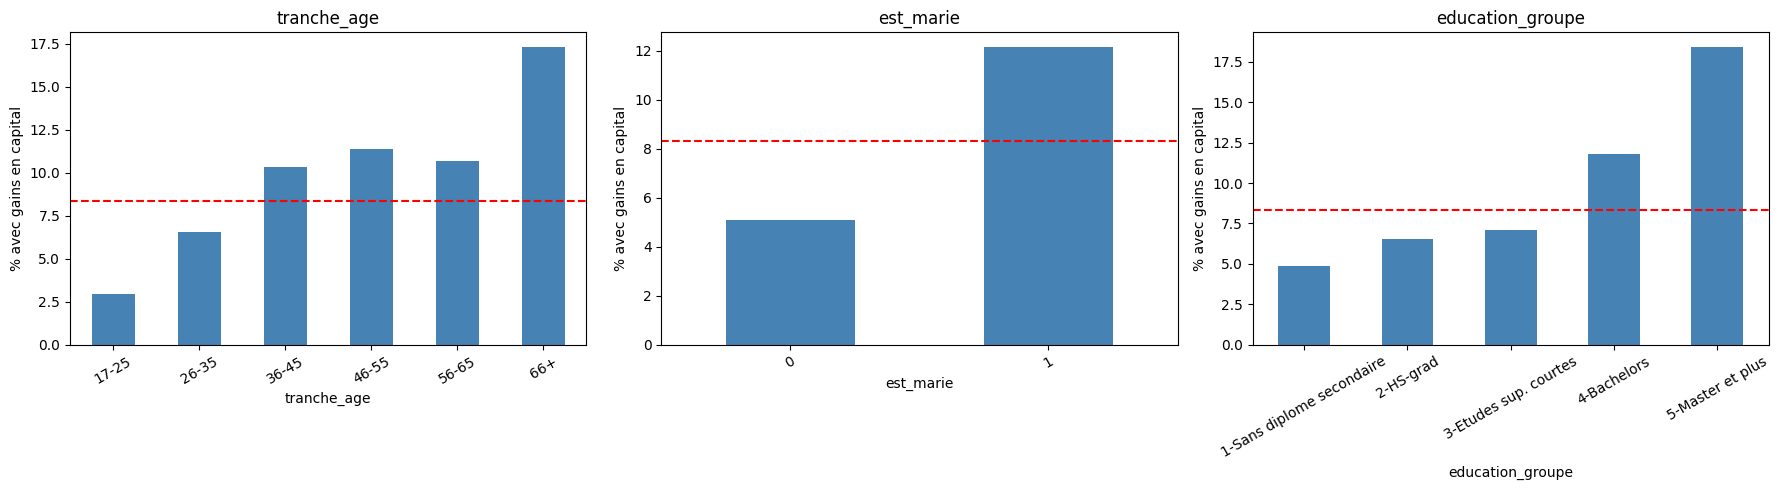

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['tranche_age', 'est_marie', 'education_groupe']):
    taux = df.groupby(col, observed=True)[target].mean() * 100
    taux.plot(kind='bar', ax=ax, color='steelblue')
    ax.axhline(df[target].mean() * 100, color='red', linestyle='--')
    ax.set_title(col)
    ax.set_ylabel("% avec gains en capital")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Lecture des graphiques :**
* **Tranche d'âge :** environ 3 % chez les 17-25 ans, contre environ 16 % chez les 66 ans et plus.
* **Marié :** environ 12 % chez les mariés, contre 5 % chez les autres.
* **Niveau d'études :** environ 5 % sans diplôme secondaire, contre environ 18 % pour Master et plus.

Les trois nouvelles variables sont donc **utiles** pour notre cible.

## Retirer les variables qui « trichent » (fuite de données)

Une **fuite de données** se produit quand une variable contient déjà la réponse. Le modèle semblerait très bon pendant l'entraînement, mais il serait inutilisable dans la réalité.

On retire :
* **`capital-gain`** : c'est elle qui a servi à créer la cible. La garder reviendrait à donner directement la réponse au modèle.
* **`capital-loss`** : on vérifie juste en dessous qu'une personne qui a une perte en capital n'a **jamais** de gain. Le recensement n'enregistre qu'un seul montant (gain ou perte). Cette variable vient donc de la même information que la cible.
* **`income`** : le revenu inclut les gains en capital. Un gros gain fait automatiquement passer le revenu au-dessus de 50K. De plus, l'organisme ne connaît pas le revenu des personnes qu'il veut cibler.
* **`fnlwgt`** : c'est un poids statistique utilisé par le recensement. Il ne décrit pas la personne.

Vérification pour `capital-loss` : on croise « a une perte » avec « a un gain ».

In [65]:
pd.crosstab(df['capital-loss'] > 0, df[target])

has_capital_gain,0,1
capital-loss,,
False,28306,2712
True,1519,0


Dans la ligne `True` (personnes avec une perte), la colonne `1` vaut **0** : aucune personne avec une perte n'a de gain. Cela confirme la fuite de données.

On supprime maintenant ces quatre colonnes.

In [66]:
df = df.drop(columns=['capital-gain', 'capital-loss', 'income', 'fnlwgt'])
df.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'hours-per-week',
       'native-country', 'has_capital_gain', 'tranche_age', 'est_marie',
       'education_groupe'],
      dtype='object')

## Retirer les variables en double

Certaines variables contiennent la même information qu'une nouvelle variable que l'on a créée. On garde une seule variable par information, et on choisit la version créée :

| Information | On garde | On retire |
|---|---|---|
| Âge | `tranche_age` | `age` |
| Niveau d'études | `education_groupe` | `education`, `education-num` |
| Situation familiale | `est_marie` | `marital-status`, `relationship` |

`relationship` est retirée car ses valeurs principales (`Husband`, `Wife`) indiquent simplement que la personne est mariée.

In [67]:
df = df.drop(columns=['age', 'education', 'education-num', 'marital-status', 'relationship'])
df.columns

Index(['workclass', 'occupation', 'race', 'sex', 'hours-per-week',
       'native-country', 'has_capital_gain', 'tranche_age', 'est_marie',
       'education_groupe'],
      dtype='object')

# Partie 3 : Transformation des données

## Encodage des variables texte

Les modèles et la matrice de corrélation ne comprennent que les nombres. On transforme donc chaque variable texte en nombres avec `LabelEncoder` (par exemple `Female` devient 0 et `Male` devient 1), comme dans le TP.

On garde une copie `df_texte` des données en texte, car on en aura besoin à la Partie 4.

In [68]:
df['tranche_age'] = df['tranche_age'].astype(str)
df_texte = df.copy()

colonnes_texte = ['workclass', 'occupation', 'race', 'sex', 'native-country', 'tranche_age', 'education_groupe']

for col in colonnes_texte:
    df[col] = LabelEncoder().fit_transform(df[col])

df.head()

,workclass,occupation,race,sex,hours-per-week,native-country,has_capital_gain,tranche_age,est_marie,education_groupe
0,6,0,4,1,40,38,1,2,0,3
1,5,3,4,1,13,38,0,3,1,3
2,3,5,4,1,40,38,0,2,0,1
3,3,5,2,1,40,38,0,3,1,0
4,3,9,2,0,40,4,0,1,1,3


## Normalisation

On met toutes les variables sur la même échelle (moyenne 0, écart-type 1) avec `StandardScaler`, comme dans le TP. Par exemple, `hours-per-week` va de 1 à 99 alors que `est_marie` vaut 0 ou 1.

On ne normalise pas la cible, car elle doit rester 0 ou 1.

In [69]:
df_normalized = df.copy()
colonnes = df.columns.drop(target)
df_normalized[colonnes] = StandardScaler().fit_transform(df[colonnes])

df_normalized.head()

,workclass,occupation,race,sex,hours-per-week,native-country,has_capital_gain,tranche_age,est_marie,education_groupe
0,1.876197,-1.483535,0.393685,0.703020,-0.035664,0.257437,1,0.145212,-0.924443,1.107560
1,1.175970,-0.790564,0.393685,0.703020,-2.222483,0.257437,0,0.878531,1.081733,1.107560
2,-0.224485,-0.328584,0.393685,0.703020,-0.035664,0.257437,0,0.145212,-0.924443,-0.661025
3,-0.224485,-0.328584,-1.962488,0.703020,-0.035664,0.257437,0,0.878531,1.081733,-1.545317
4,-0.224485,0.595376,-1.962488,-1.422436,-0.035664,-5.352003,0,-0.588106,1.081733,1.107560


# Partie 4 : Sélection des caractéristiques

## Matrice de corrélation

La matrice de corrélation montre le lien entre chaque paire de variables. Une valeur proche de **1** ou **-1** indique un lien fort, une valeur proche de **0** indique un lien faible.

On s'intéresse surtout à la **dernière ligne/colonne**, celle de la cible `has_capital_gain`.

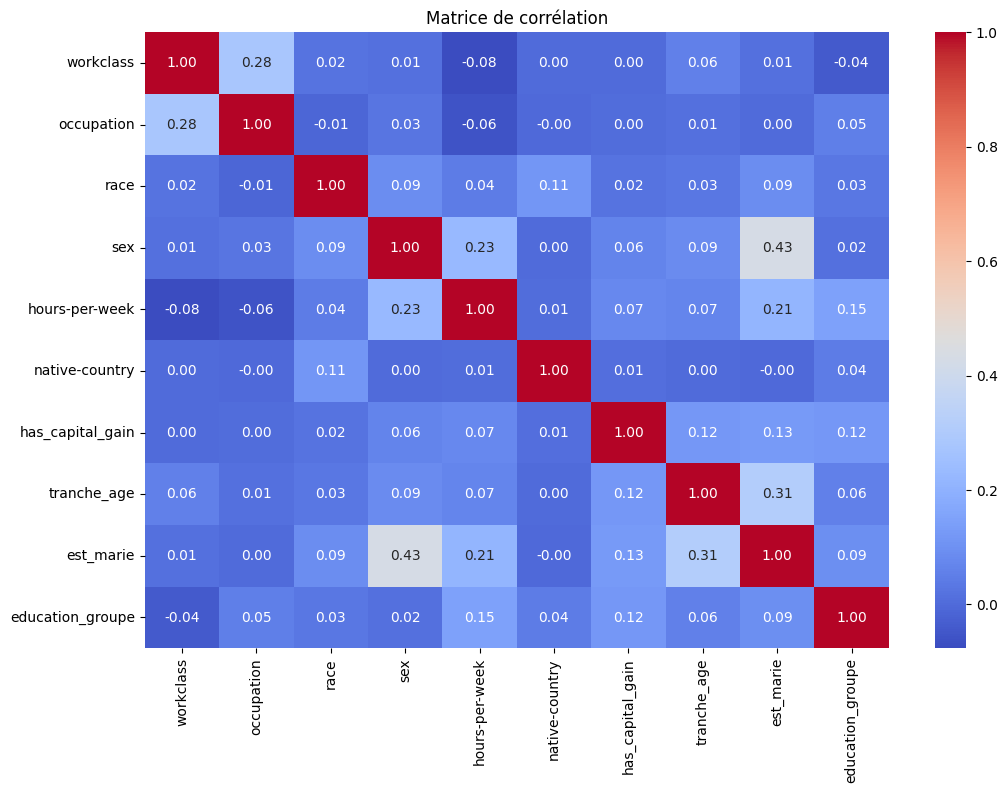

In [70]:
plt.figure(figsize=(12, 8))
corr_matrix = df_normalized.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()

## Corrélations avec la cible

On affiche uniquement la corrélation de chaque variable avec la cible. On prend la valeur absolue, car un lien négatif fort est aussi utile qu'un lien positif fort.

In [71]:
corr_matrix[target].abs().drop(target).sort_values(ascending=False)

,has_capital_gain
est_marie,0.127441
education_groupe,0.119634
tranche_age,0.118966
hours-per-week,0.074979
sex,0.064760
race,0.023615
native-country,0.011516
occupation,0.004422
workclass,0.000200


## Limite de la corrélation pour les variables texte

La corrélation fonctionne bien pour les variables qui sont de **vrais nombres** (`hours-per-week`) ou qui n'ont que **deux valeurs** (`est_marie`, `sex`).

Mais pour une variable texte avec beaucoup de catégories, comme `occupation`, le `LabelEncoder` a donné les numéros 0, 1, 2… **par ordre alphabétique**. Ces numéros n'ont pas de sens : `Adm-clerical` = 0 n'est pas « plus petit » que `Sales` = 11. La corrélation calculée sur ces numéros n'est donc pas fiable.

**Solution :** pour ces variables, on utilise le **V de Cramér**. C'est l'équivalent de la corrélation pour les variables texte. Il se calcule à partir du test du khi-deux et donne une valeur entre **0** (aucun lien) et **1** (lien parfait). Il ne dépend pas de l'ordre des catégories.

In [72]:
def v_de_cramer(x, y):
    tableau = pd.crosstab(x, y)
    chi2 = chi2_contingency(tableau)[0]
    n = tableau.values.sum()
    return np.sqrt(chi2 / (n * (min(tableau.shape) - 1)))

## Tableau final des scores

On calcule un score pour chaque variable :
* **Corrélation** (Pearson, celle de la matrice) pour les variables numériques ou à deux valeurs : `hours-per-week`, `est_marie`, `sex`.
* **V de Cramér** pour les variables texte à plusieurs catégories : on utilise `df_texte`, la copie gardée avant l'encodage.

In [73]:
variables_numeriques = ['hours-per-week', 'est_marie', 'sex']
variables_texte = ['tranche_age', 'education_groupe', 'occupation', 'workclass', 'race', 'native-country']

scores = {}
for col in variables_numeriques:
    scores[col] = abs(corr_matrix.loc[col, target])
for col in variables_texte:
    scores[col] = v_de_cramer(df_texte[col], df_texte[target])

scores = pd.Series(scores).sort_values(ascending=False).round(3)
scores

,0
education_groupe,0.133
tranche_age,0.128
est_marie,0.127
occupation,0.122
hours-per-week,0.075
workclass,0.073
sex,0.065
native-country,0.044
race,0.032


**Remarque importante :** dans la matrice de corrélation, `occupation` avait un score presque nul (environ 0.002), alors qu'avec le V de Cramér son score est d'environ 0.12. Cela montre bien que la corrélation calculée sur des numéros arbitraires peut cacher une variable utile.

On visualise ces scores. La ligne verte (0.10) est le seuil des variables **principales**, la ligne orange (0.05) le seuil des variables **secondaires**.

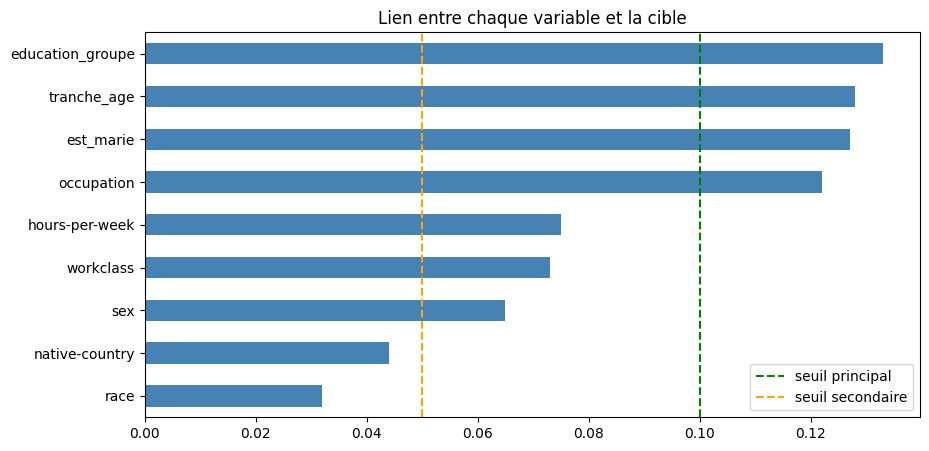

In [74]:
plt.figure(figsize=(10, 5))
scores.sort_values().plot(kind='barh', color='steelblue')
plt.axvline(0.10, color='green', linestyle='--', label='seuil principal')
plt.axvline(0.05, color='orange', linestyle='--', label='seuil secondaire')
plt.title("Lien entre chaque variable et la cible")
plt.legend()
plt.show()

## Choisir les caractéristiques principales et secondaires

On applique deux seuils, comme le seuil de 0.1 utilisé dans le TP :
* **Principales :** score supérieur ou égal à **0.10** (lien clair avec la cible).
* **Secondaires :** score entre **0.05** et **0.10** (lien plus faible mais présent).
* **Écartées :** score inférieur à **0.05** (lien trop faible).

In [75]:
features_principales = scores[scores >= 0.10].index.tolist()
features_secondaires = scores[(scores >= 0.05) & (scores < 0.10)].index.tolist()
features_ecartees = scores[scores < 0.05].index.tolist()

print("Principales :", features_principales)
print("Secondaires :", features_secondaires)
print("Écartées    :", features_ecartees)

Principales : ['education_groupe', 'tranche_age', 'est_marie', 'occupation']
Secondaires : ['hours-per-week', 'workclass', 'sex']
Écartées    : ['native-country', 'race']


## Conclusion de la sélection

| Rôle | Variable | Explication |
|---|---|---|
| **Principale** | `education_groupe` | Plus le niveau d'études est élevé, plus on a de gains en capital |
| **Principale** | `tranche_age` | Les personnes plus âgées ont plus souvent des gains |
| **Principale** | `est_marie` | Les personnes mariées ont deux fois plus souvent des gains |
| **Principale** | `occupation` | Les cadres et professions intellectuelles ont plus souvent des gains |
| **Secondaire** | `hours-per-week` | Lien plus faible avec la cible |
| **Secondaire** | `workclass` | Les indépendants ont plus souvent des gains |
| **Secondaire** | `sex` | Lien faible, à utiliser avec prudence (risque de ciblage discriminant) |
| Écartée | `race`, `native-country` | Lien trop faible, et ce sont des variables sensibles |
| Écartée | `capital-gain`, `capital-loss`, `income` | Fuite de données |
| Écartée | `fnlwgt` | Poids statistique sans signification pour la personne |

Les trois variables créées (tranche d'âge, marié, niveau d'études regroupé) font toutes partie des variables **principales**. Cela confirme les choix de l'objectif Data Science.

## Créer le DataFrame avec les caractéristiques sélectionnées

On garde uniquement les variables principales et secondaires, plus la cible, comme à la fin du TP.

In [76]:
df_selected = df_normalized[features_principales + features_secondaires + [target]]
df_selected.head()

,education_groupe,tranche_age,est_marie,occupation,hours-per-week,workclass,sex,has_capital_gain
0,1.107560,0.145212,-0.924443,-1.483535,-0.035664,1.876197,0.703020,1
1,1.107560,0.878531,1.081733,-0.790564,-2.222483,1.175970,0.703020,0
2,-0.661025,0.145212,-0.924443,-0.328584,-0.035664,-0.224485,0.703020,0
3,-1.545317,0.878531,1.081733,-0.328584,-0.035664,-0.224485,0.703020,0
4,1.107560,-0.588106,1.081733,0.595376,-0.035664,-0.224485,-1.422436,0


Enfin, on sépare les variables explicatives **X** et la cible **y**. Ce sont les données qui serviront à entraîner le modèle de classification à l'étape suivante.

In [77]:
X = df_selected.drop(columns=[target])
y = df_selected[target]

print("X :", X.shape)
print("y :", y.shape)

X : (32537, 7)
y : (32537,)
